**Hello Everyone on this notebook we'll learn how to predict the handwritten numbers using the famous dataset called 'MNIST' by creating a Neural Network and predict them and visualize them graphically**

In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as pt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [13]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [14]:
X_train = X_train / 255.0 
X_test = X_test / 255.0

In [19]:
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

In [20]:
print("Training : ", X_train.shape)
print("Testing : ", X_test.shape)

Training :  (60000, 784)
Testing :  (10000, 784)


In [16]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [18]:
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9286 - loss: 0.2426 - val_accuracy: 0.9623 - val_loss: 0.1227
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9685 - loss: 0.1050 - val_accuracy: 0.9700 - val_loss: 0.0959
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9770 - loss: 0.0734 - val_accuracy: 0.9756 - val_loss: 0.0768
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9819 - loss: 0.0574 - val_accuracy: 0.9752 - val_loss: 0.0820
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9869 - loss: 0.0419 - val_accuracy: 0.9743 - val_loss: 0.0855
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9888 - loss: 0.0346 - val_accuracy: 0.9763 - val_loss: 0.0845
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9902 - loss: 0.0290 - val_accuracy: 0.9771 - val_loss: 0.0940
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9920 - loss: 0.0241 - 

**Above we trained the model with 3 layers of 128, 64, 10 neurons now let's visualize them  how well it has predicted it and evaluate them**

In [21]:
prediction = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  


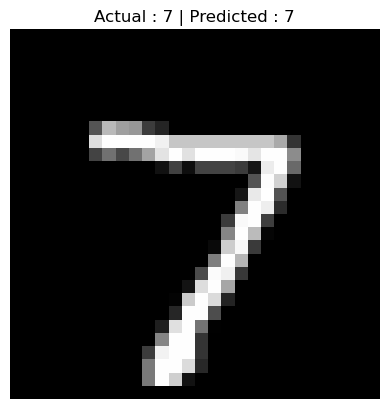

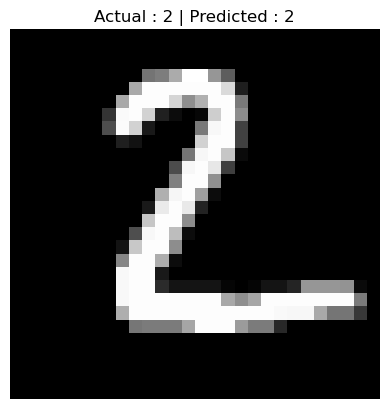

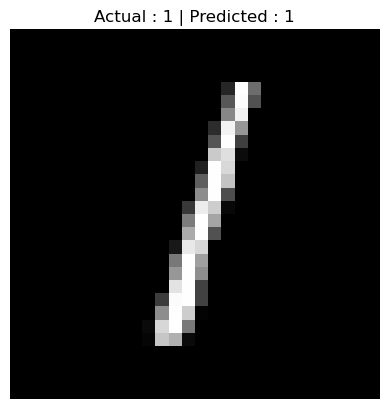

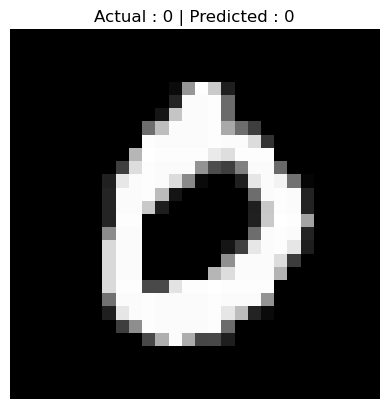

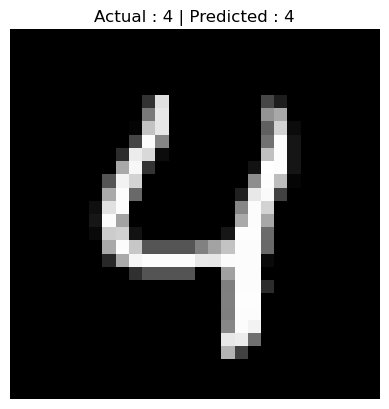

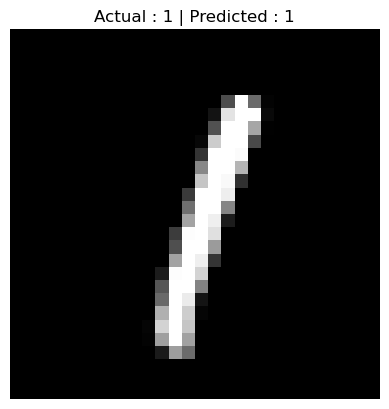

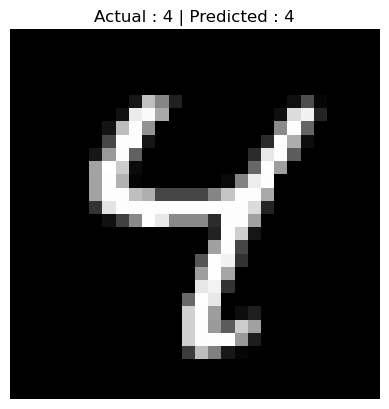

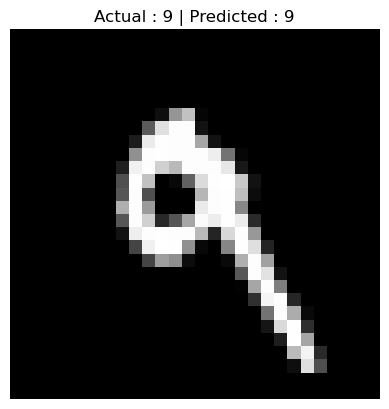

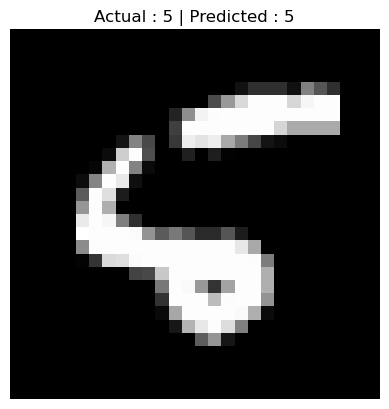

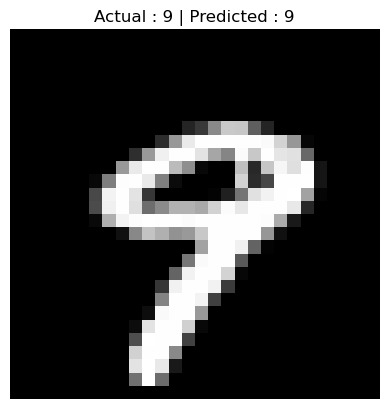

In [22]:
for i in range(10):
    pt.imshow(X_test[i].reshape(28, 28), cmap='grey')
    pt.title(f"Actual : {y_test[i]} | Predicted : {np.argmax(prediction[i])}")
    pt.axis('off')
    pt.show()

In [27]:
print(classification_report(y_test, np.argmax(prediction, axis=1)))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.98      0.98      0.98      1010
           4       0.99      0.98      0.98       982
           5       0.97      0.98      0.97       892
           6       0.98      0.97      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [28]:
print("Accuracy Score : ", accuracy_score(y_test, np.argmax(prediction, axis=1)))

Accuracy Score :  0.9779


In [30]:
print(confusion_matrix(y_test, np.argmax(prediction, axis=1)))

[[ 970    0    1    1    0    0    3    1    3    1]
 [   0 1126    2    1    0    1    1    2    2    0]
 [   3    1 1000    3    2    1    2    8   11    1]
 [   1    1    3  985    0    4    0    7    5    4]
 [   0    0    3    0  959    0    4    3    0   13]
 [   1    1    0    8    0  871    6    0    4    1]
 [   3    3    1    0    6    9  932    0    4    0]
 [   1    4    7    1    0    1    0 1007    1    6]
 [   3    0    3    3    1    8    4    3  942    7]
 [   2    2    0    6    4    4    0    1    3  987]]


**So we took randomly 10 numbers and predicted those numbers and it has predicted them preciously with ~98% accuracy it means it has trained perfectly**